In [1]:
from tqdm import tqdm
import jax.numpy as jnp
from flax import nnx
import matplotlib.pyplot as plt
import numpy as np 

## Introduction to Netket's NQS Implementation. 

Here, I just play around with 1D Ising Chain with external field,
and compare exact diagonalization (supplied by scipy.sparse.linalg) 
result with 1-layer feed forward neural network

In [2]:
import netket as nk

N = 10
hi = nk.hilbert.Spin(s=1/2, N=N)

/Users/sanzhar123/Desktop/Approximate-Symmetries-TC-main/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
import jax

hi.random_state(jax.random.key(30), 1)

Array([[ 1,  1,  1,  1,  1,  1,  1, -1, -1,  1]], dtype=int8)

In [4]:
from netket.operator.spin import sigmax, sigmaz

Gamma = -1
Ham = sum([Gamma * sigmax(hi, i) for i in range(N)])

V = -1
Ham += sum([V * sigmaz(hi, i) @ sigmaz(hi, (i + 1) % N) for i in range(N)])

sp_h = Ham.to_sparse()
sp_h.shape

(1024, 1024)

In [5]:
from scipy.sparse.linalg import eigsh

eig_vals, eig_vecs = eigsh(sp_h, k=2, which="SA")

print("eigenvalues with scipy sparse:", eig_vals)

E_gs = eig_vals[0]

eigenvalues with scipy sparse: [-12.78490644 -12.62750303]


In [6]:
class FFN(nnx.Module):

    def __init__(self, N: int, alpha: int = 1, *, rngs: nnx.Rngs):
        """
        Construct a Feed-Forward Neural Network with a single hidden layer.

        Args:
            N: The number of input nodes (number of spins in the chain).
            alpha: The density of the hidden layer. The hidden layer will have
                N*alpha nodes.
            rngs: The random number generator seed.
        """
        self.alpha = alpha

        # We define a linear (or dense) layer with `alpha` times the number of input nodes
        # as output nodes.
        # We must pass forward the rngs object to the dense layer.
        self.linear = nnx.Linear(in_features=N, out_features=alpha * N, rngs=rngs)

    def __call__(self, x: jax.Array):

        # we apply the linear layer to the input
        y = self.linear(x)

        # the non-linearity is a simple ReLu
        y = nnx.relu(y)

        # sum the output
        return jnp.sum(y, axis=-1)

model = FFN(N=N, alpha=1, rngs=nnx.Rngs(2))
sampler = nk.sampler.MetropolisLocal(hi)
vstate = nk.vqs.MCState(sampler, model, n_samples=1008)
optimizer = nk.optimizer.Sgd(learning_rate=0.1)

# Notice the use, again of Stochastic Reconfiguration, which considerably improves the optimization
gs = nk.driver.VMC(
    Ham,
    optimizer,
    variational_state=vstate,
    preconditioner=nk.optimizer.SR(diag_shift=0.1),
)

In [7]:
log = nk.logging.RuntimeLog()
gs.run(n_iter=300, out=log)

100%|██████████| 300/300 [00:03<00:00, 79.22it/s, Energy=-12.7821 ± 0.0091 [σ²=0.0828, R̂=1.0031]]


(RuntimeLog():
  keys = ['acceptance', 'Energy'],)

In [8]:
ffn_energy = vstate.expect(Ham)
error = abs((ffn_energy.mean - eig_vals[0]) / eig_vals[0])
print("Optimized energy and relative error: ", ffn_energy, error)

Optimized energy and relative error:  -12.7771 ± 0.0075 [σ²=0.0572, R̂=1.0086] 0.000608675064150713


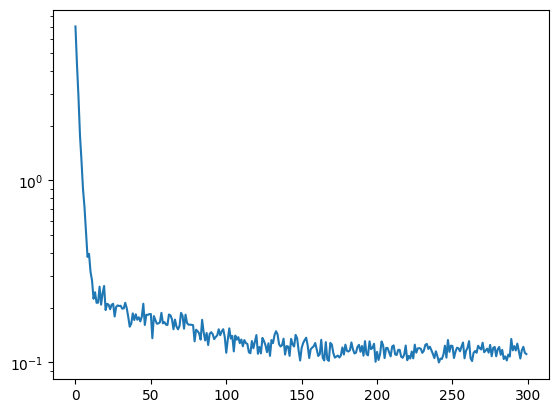

In [9]:
Energy_list = log.data['Energy']['Mean']

plt.plot(np.arange(len(Energy_list)), Energy_list - min(Energy_list) + 1e-1)
# plt.plot(np.arange(len(Energy_list)), Energy_list)
plt.yscale('log')
plt.show()

## Using Netket and 2D Toric Code Hamiltonian to map out phase diagram. 

The plan is as follows. For a given L, write down Hamiltonian, 
and using Krylov Diagonalization find an approximate ground state (gs)
energy and gs wavefunction. Measure the A_v, sigma_z operators. 
We fix the value of h_x = 0.3, and sweep h_z from 0.0 to 0.75, 
looking for non-analyticity.

Another avenue latet woulbe - pick a Approx. Symm. Ansatz, 
run the NQS algorithm to obtain a ground state, and 
measure the A_v, sigma_z operators. We fix the value of h_x = 0.3, 
and sweep h_z from 0.0 to 0.75, looking for non-analyticity.

In [10]:
from model.geometry import ToricCodeGeometry
from model.hamiltonian import create_hamiltonian

geometry = ToricCodeGeometry(3, 3, 'PBC')

# Create the Hilbert space
hi = nk.hilbert.Spin(s=1/2, N=geometry.N)
    
# Create the Hamiltonian
Ham = create_hamiltonian(
    hi=hi,
    vertex_all=geometry.vertex_all,
    plaq_all=geometry.plaq_all,
    bonds=geometry.bonds,
    hx=0.0,
    hy=0.0,
    hz=0.0,
)

/Users/sanzhar123/Desktop/Approximate-Symmetries-TC-main/.venv/lib/python3.13/site-packages/netket/graph/lattice.py:329: UserWarning: Some atom positions are not unique. Duplicates were dropped, and now atom positions are [0.5]
  warnings.warn(


In [11]:
# Krylov Diagonalization 
eig_vals, eig_vecs = eigsh(Ham.to_sparse(), k=2, which="SA", return_eigenvectors=True)

print("eigenvalues with scipy sparse:", eig_vals)
E_gs = eig_vals[0]
wave_gs = eig_vecs.transpose()[0]

eigenvalues with scipy sparse: [-18. -18.]


In [12]:
# Observables: star sum A = Σ_v A_v, plaquette sum B = Σ_p B_p, magnetization Σ_i σ^z_i.
stars = geometry.get_vertex_all_hetero()
plaqs = geometry.plaq_all
N_v, N_p, N = len(stars), len(plaqs), geometry.N

A_op = 0
for star in stars:
    term = 1
    for i in star:
        term *= sigmax(hi, i)
    A_op += term

B_op = 0
for plaq in plaqs:
    term = 1
    for i in plaq:
        term *= sigmaz(hi, i)
    B_op += term

Mz_op = sum(sigmaz(hi, i) for i in range(N))

A_sp, B_sp, Mz_sp = A_op.to_sparse(), B_op.to_sparse(), Mz_op.to_sparse()

In [13]:
# Zero-field sanity check: every stabilizer is +1 in the unperturbed GS.
def expect(O, psi):
    return (psi.conj() @ O @ psi).real

print(f"<A_v> = {expect(A_sp, wave_gs) / N_v:.6f}")
print(f"<B_p> = {expect(B_sp, wave_gs) / N_p:.6f}")
print(f"<σ_z> = {expect(Mz_sp, wave_gs) / N:.6f}")

<A_v> = 1.000000
<B_p> = 1.000000
<σ_z> = 0.000000


In [198]:
h_z_list = np.linspace(0, 0.75, 20)
records = {k: [] for k in ("h_z", "E0", "gap", "A", "B", "Mz")}

for h_z in tqdm(h_z_list):
    Ham = create_hamiltonian(
        hi=hi,
        vertex_all=geometry.vertex_all,
        plaq_all=geometry.plaq_all,
        bonds=geometry.bonds,
        hx=0.3, hy=0.0, hz=h_z,
    )
    eig_vals, eig_vecs = eigsh(Ham.to_sparse(), k=4, which="SA", return_eigenvectors=True)
    psi = eig_vecs[:, 0]

    records["h_z"].append(h_z)
    records["E0"].append(eig_vals[0])
    records["gap"].append(eig_vals[1] - eig_vals[0])
    records["A"].append(expect(A_sp, psi) / N_v)
    records["B"].append(expect(B_sp, psi) / N_p)
    records["Mz"].append(expect(Mz_sp, psi) / N)

records = {k: np.array(v) for k, v in records.items()}

100%|██████████| 20/20 [02:42<00:00,  8.13s/it]


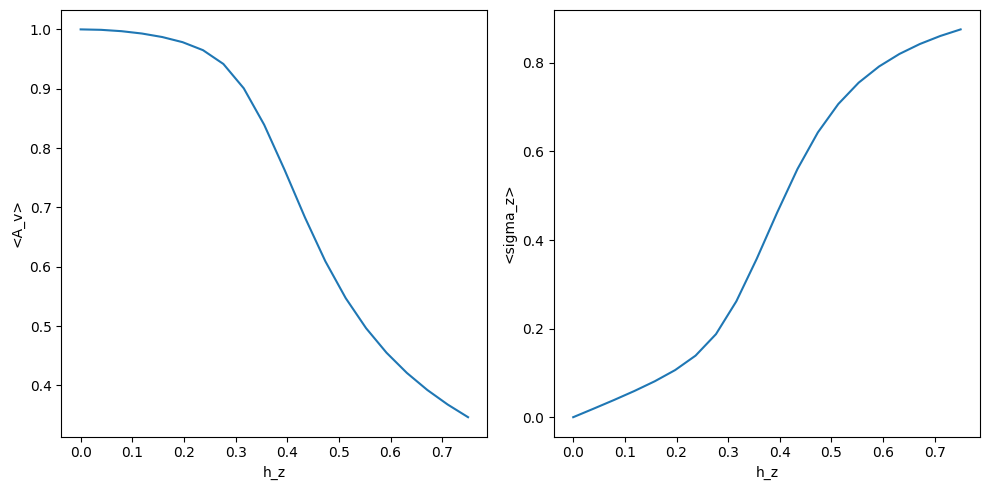

In [206]:
fig, axs = plt.subplots(1, 2, figsize=(10, 5))

axs[0].plot(records['h_z'], records['A'])
axs[0].set_xlabel('h_z')
axs[0].set_ylabel('<A_v>')

axs[1].plot(records['h_z'], records['Mz'])
axs[1].set_xlabel('h_z')
axs[1].set_ylabel('<sigma_z>')

# axs[2].plot(records['h_z'], records['gap'])
# axs[2].set_xlabel('h_z')
# axs[2].set_ylabel('E_0 - E_1')

plt.tight_layout() 

## Rotated surface code: same transition, half the qubits

The edge-qubit TC needs $2L^2$ qubits, so $L=4$ PBC is out of reach.  Rotating
the lattice puts qubits on **vertices**: $d^2$ qubits, plus a checkerboard of
weight-4 $X$- and $Z$-plaquettes and weight-2 boundary stabilizers.  Same
universality class as the TC, much smaller Hilbert space per code distance.
Concretely: $d=3 \to 9$ qubits, $d=4 \to 16$ qubits.

We reuse `create_hamiltonian` (which expects vertex-X / plaquette-Z lists) and
the same observables, so the only new ingredient is the geometry class.

In [24]:
from model.rotated_surface import RotatedSurfaceGeometry
from model.exact_diag import (
    hamiltonian_linop, expect_x_string, expect_z_string, qubits_to_mask,
)

def sweep_phase_diagram(geom, h_z_list, hx=0.3, k=4, label=""):
    """KD sweep over h_z at fixed h_x for a rotated surface code geometry.

    Matrix-free Lanczos (scipy LinearOperator backed by an on-the-fly matvec) —
    no sparse matrix is materialised, so this scales to d=5 (25 qubits, 33M dim)
    where Ham.to_sparse() becomes painful.

    Returns dict of arrays keyed by:
      h_z, E0, gap, A, B, Mz, Wx, Wz, Ox, Oz, bffm_x, bffm_z
    """
    N = geom.N
    basis = np.arange(1 << N, dtype=np.int64)

    cx, ox, cz, oz = geom.wilson_paths()
    masks = {
        "cx": qubits_to_mask(cx), "ox": qubits_to_mask(ox),
        "cz": qubits_to_mask(cz), "oz": qubits_to_mask(oz),
    }
    star_masks = [qubits_to_mask(s) for s in geom.get_vertex_all_hetero()]
    plaq_masks = [qubits_to_mask(p) for p in geom.plaq_all]
    site_masks = [1 << i for i in range(N)]

    keys = ("h_z", "E0", "gap", "A", "B", "Mz",
            "Wx", "Wz", "Ox", "Oz", "bffm_x", "bffm_z")
    rec = {k: [] for k in keys}

    for h_z in tqdm(h_z_list, desc=label):
        H, _ = hamiltonian_linop(geom, hx=hx, hy=0.0, hz=float(h_z), J=1.0)
        ev, vc = eigsh(H, k=k, which="SA", return_eigenvectors=True)
        psi = vc[:, 0]

        Wx = expect_x_string(psi, basis, masks["cx"])
        Ox = expect_x_string(psi, basis, masks["ox"])
        Wz = expect_z_string(psi, basis, masks["cz"], N)
        Oz = expect_z_string(psi, basis, masks["oz"], N)

        rec["h_z"].append(float(h_z))
        rec["E0"].append(float(ev[0]))
        rec["gap"].append(float(ev[1] - ev[0]))
        rec["A"].append(float(np.mean([expect_x_string(psi, basis, m) for m in star_masks])))
        rec["B"].append(float(np.mean([expect_z_string(psi, basis, m, N) for m in plaq_masks])))
        rec["Mz"].append(float(np.mean([expect_z_string(psi, basis, m, N) for m in site_masks])))
        rec["Wx"].append(Wx); rec["Ox"].append(Ox)
        rec["Wz"].append(Wz); rec["Oz"].append(Oz)
        rec["bffm_x"].append(Ox / np.sqrt(abs(Wx)) if abs(Wx) > 1e-14 else np.nan)
        rec["bffm_z"].append(Oz / np.sqrt(abs(Wz)) if abs(Wz) > 1e-14 else np.nan)

    return {k: np.array(v) for k, v in rec.items()}


In [25]:
h_z_list = np.linspace(0, 0.75, 50)
runs = {
    "d=3 surface": sweep_phase_diagram(RotatedSurfaceGeometry(3), h_z_list, label="d=3"),
    "d=4 surface": sweep_phase_diagram(RotatedSurfaceGeometry(4), h_z_list, label="d=4"),
    # "d=5 surface": sweep_phase_diagram(RotatedSurfaceGeometry(5), h_z_list, label="d=5"),
    # d=5 is 25 qubits / 33M states; needs >8 GB RAM to run as-is.
}


d=4: 100%|██████████| 50/50 [00:40<00:00,  1.23it/s]


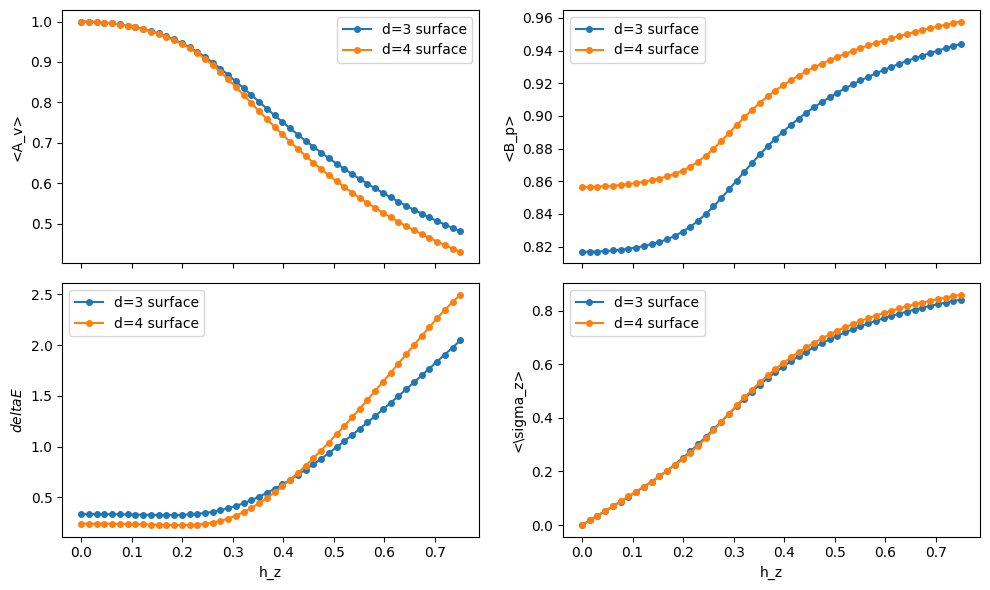

In [26]:
fig, axes = plt.subplots(2, 2, figsize=(10, 6), sharex=True)
panels = [
    ("A",   r"<A_v>"),
    ("B",   r"<B_p>"),
    ("gap", r"$delta E$"),
    ("Mz",  r"<\sigma_z>"),
]

for ax, (key, ylabel) in zip(axes.flat, panels):
    for label, rec in runs.items():
        ax.plot(rec["h_z"], rec[key], "o-", markersize=4, label=label)
    ax.set_ylabel(ylabel)
    ax.legend()

for ax in axes[-1]:
    ax.set_xlabel(r"h_z")

fig.tight_layout()
plt.show()

### BFFM string order parameter and its $h_z$ derivative

Both $O_{BFFM}^{X/Z}$ are computed in the matrix-free sweep above from the half-string and full-string Wilson paths returned by `RotatedSurfaceGeometry.wilson_paths()` (defaults: horizontal row of $\sigma^x$ across the lattice for X, vertical column of $\sigma^z$ for Z; open halves use the first $\lceil d/2 \rceil$ sites).  The transition signature lives in $\partial O_{BFFM}^Z / \partial h_z$ (sweep is along $h_z$), and the peak should sharpen / shift with $d$ — that's the headline diagnostic.

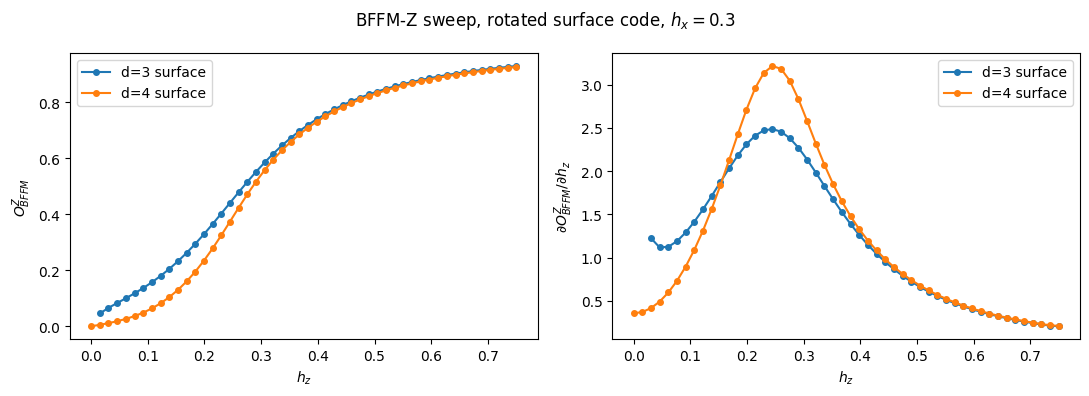

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

for label, rec in runs.items():
    axes[0].plot(rec["h_z"], rec["bffm_z"], "o-", markersize=4, label=label)
    deriv = np.gradient(rec["bffm_z"], rec["h_z"])
    axes[1].plot(rec["h_z"], deriv, "o-", markersize=4, label=label)

axes[0].set_ylabel(r"$O_{BFFM}^Z$")
axes[1].set_ylabel(r"$\partial O_{BFFM}^Z / \partial h_z$")
for ax in axes:
    ax.set_xlabel(r"$h_z$")
    ax.legend()

fig.suptitle(r"BFFM-Z sweep, rotated surface code, $h_x=0.3$")
fig.tight_layout()
plt.show()


## 3D bosonic toric code, L=2 PBC, matrix-free KD sweep

Same matrix-free Lanczos approach, generalized to the 3D toric code Hamiltonian built by `Three_TC/model/geometry.py`.  At L=2 PBC we have $N = 3 \cdot 2^3 = 24$ qubits ($2^{24} \approx 16.8$ M states) — well within reach.  L=3 PBC would give $N = 81$, well past anything `eigsh` can handle.

The wonderful thing is that `model/exact_diag.py` is geometry-agnostic — it only consumes `geom.N`, `geom.vertex_all`, `geom.plaq_all`.  Both the 2D rotated surface and the 3D toric code geometries satisfy that interface, so we reuse the module verbatim.  Only the Wilson-string helper changes: in 3D PBC, the natural closed $\sigma^z$ loop is a line of qubits wrapping around the torus in one direction.

In [28]:
from Three_TC.model.geometry import ThreeD_ToricCodeGeometry

geom_3d = ThreeD_ToricCodeGeometry(2, 2, 2, 'PBC')
print(f'3D TC L=2 PBC:  N = {geom_3d.N},  |A_v| = {len(geom_3d.vertex_all)},  '
      f'|B_p| = {len(geom_3d.plaq_all)},  dim = 2^{geom_3d.N} = {1<<geom_3d.N:,}')

def z_line_qubits(geom, x: int = 0, y: int = 0):
    """Qubit indices of the sigma^z edges along the z-axis at column (x, y), PBC L=geom.Lz."""
    Lx2, Ly2, Lz2 = 2 * geom.Lx, 2 * geom.Ly, 2 * geom.Lz
    return [geom._coord_to_idx[((2 * x) % Lx2, (2 * y) % Ly2, (2 * z + 1) % Lz2)]
            for z in range(geom.Lz)]

closed_z3d = z_line_qubits(geom_3d, 0, 0)
open_z3d   = closed_z3d[: max(1, len(closed_z3d) // 2)]
print(f'closed Z-line: {closed_z3d}   open Z-string: {open_z3d}')

3D TC L=2 PBC:  N = 24,  |A_v| = 8,  |B_p| = 24,  dim = 2^24 = 16,777,216
closed Z-line: [8, 20]   open Z-string: [8]


In [29]:
# Zero-field sanity check: E0 = -(N_v + N_p), every stabilizer +1.
H, basis_3d = hamiltonian_linop(geom_3d, hx=0.0, hz=0.0, J=1.0)
ev, vc = eigsh(H, k=4, which='SA', tol=1e-7)
print(f'eigenvalues: {ev}')
psi = vc[:, 0]
A_vals = [expect_x_string(psi, basis_3d, qubits_to_mask(v)) for v in geom_3d.vertex_all]
B_vals = [expect_z_string(psi, basis_3d, qubits_to_mask(p), geom_3d.N) for p in geom_3d.plaq_all]
print(f'mean <A_v> = {np.mean(A_vals):.4f}    (expect 1.0)')
print(f'mean <B_p> = {np.mean(B_vals):.4f}    (expect 1.0)')
print(f'E0 = {ev[0]:.4f}                       (expect -{len(geom_3d.vertex_all) + len(geom_3d.plaq_all)})')

eigenvalues: [-32. -32. -28. -28.]
mean <A_v> = 1.0000    (expect 1.0)
mean <B_p> = 1.0000    (expect 1.0)
E0 = -32.0000                       (expect -32)


In [ ]:
def sweep_phase_diagram_3d(geom, h_z_list, hx=0.2, k=2, label="3D L=2 PBC"):
    """Matrix-free KD sweep over h_z for the 3D toric code."""
    N = geom.N
    basis = np.arange(1 << N, dtype=np.int64)

    cz = z_line_qubits(geom, 0, 0)
    oz = cz[: max(1, len(cz) // 2)]
    cz_mask, oz_mask = qubits_to_mask(cz), qubits_to_mask(oz)
    star_masks = [qubits_to_mask(v) for v in geom.vertex_all]
    plaq_masks = [qubits_to_mask(p) for p in geom.plaq_all]
    site_masks = [1 << i for i in range(N)]

    keys = ("h_z", "E0", "gap", "A", "B", "Mz", "Wz", "Oz", "bffm_z")
    rec = {k: [] for k in keys}

    for h_z in tqdm(h_z_list, desc=label):
        H, _ = hamiltonian_linop(geom, hx=hx, hy=0.0, hz=float(h_z), J=1.0)
        ev, vc = eigsh(H, k=k, which="SA", tol=1e-7, return_eigenvectors=True)
        psi = vc[:, 0]
        Wz = expect_z_string(psi, basis, cz_mask, N)
        Oz = expect_z_string(psi, basis, oz_mask, N)
        rec["h_z"].append(float(h_z))
        rec["E0"].append(float(ev[0]))
        rec["gap"].append(float(ev[1] - ev[0]))
        rec["A"].append(float(np.mean([expect_x_string(psi, basis, m) for m in star_masks])))
        rec["B"].append(float(np.mean([expect_z_string(psi, basis, m, N) for m in plaq_masks])))
        rec["Mz"].append(float(np.mean([expect_z_string(psi, basis, m, N) for m in site_masks])))
        rec["Wz"].append(Wz); rec["Oz"].append(Oz)
        rec["bffm_z"].append(Oz / np.sqrt(abs(Wz)) if abs(Wz) > 1e-14 else np.nan)

    return {k: np.array(v) for k, v in rec.items()}

rec_3d = sweep_phase_diagram_3d(geom_3d, h_z_list, hx=0.2, label="3D L=2 PBC")

3D L=2 PBC:   0%|          | 0/50 [00:00<?, ?it/s]

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(rec_3d["h_z"], rec_3d["bffm_z"], "o-", color="C2", label="3D L=2 PBC")
axes[1].plot(rec_3d["h_z"], np.gradient(rec_3d["bffm_z"], rec_3d["h_z"]),
             "o-", color="C2", label="3D L=2 PBC")
axes[0].set_ylabel(r"$O_{BFFM}^Z$")
axes[1].set_ylabel(r"$\partial O_{BFFM}^Z / \partial h_z$")
for ax in axes:
    ax.set_xlabel(r"$h_z$")
    ax.legend()
fig.suptitle(r"3D bosonic TC, $h_x = 0.3$, $\sigma^z$ z-line")
fig.tight_layout()
plt.show()

Now is the time for Fermionic toric code. The only that changes is the hamiltonian of the system, and the rest fo the pipeline should work as before (3D Bosonic Toric Code).

The Hamiltonian change is one line: feed the decorated plaquette set
`fermionic_plaquettes(geom)` to `hamiltonian_linop` as `xz_stabs=`.  Each
plaquette becomes $\tilde B_p = (\prod_{e\in\partial p}\sigma^z_e)\,
\sigma^x_{e_+}\sigma^x_{e_-}$ with the two $\sigma^x$ on opposite transverse
corner edges (see `model/fermionic_decoration.py`).  Vertex stars, the
matrix-free pipeline and the eigsh sweep are reused verbatim.

**Caveat on the order parameter.**  The bare $\sigma^z$ z-line wrapping the
torus anticommutes with 4 of the decorated plaquettes, so it is *not* a
conserved Wilson string here (unlike the bosonic case).  We keep the same BFFM
z-line for now to see what it does; if it turns out uninformative we will build
a $\sigma^x$-dressed (conserved) string instead.  The spectral gap and $\langle
M_z\rangle$ remain well-defined transition diagnostics.

In [ ]:
from Three_TC.model.fermionic_decoration import fermionic_plaquettes, verify_xz_commutation
from model.exact_diag import expect_xz_string

geom_3df = ThreeD_ToricCodeGeometry(2, 2, 2, 'PBC')
stabs_f = fermionic_plaquettes(geom_3df, J=1.0)
chk = verify_xz_commutation(stabs_f, geom_3df.vertex_all)
print(f'fermionic 3D TC L=2 PBC:  N = {geom_3df.N},  |A_v| = {len(geom_3df.vertex_all)},  '
      f'|B~_p| = {len(stabs_f)},  commute = {chk["ok"]}  ({len(chk["violations"])} violations)')

# Reuse the bosonic wrapping sigma^z z-line as the (bare) BFFM string.
closed_z3df = z_line_qubits(geom_3df, 0, 0)
open_z3df   = closed_z3df[: max(1, len(closed_z3df) // 2)]

In [ ]:
# Zero-field sanity check: E0 = -(N_v + N_p), every decorated stabilizer +1.
H, basis_3df = hamiltonian_linop(geom_3df, hx=0.0, hz=0.0, J=1.0, xz_stabs=stabs_f)
ev, vc = eigsh(H, k=4, which='SA', tol=1e-7)
print(f'eigenvalues: {ev}')
psi = vc[:, 0]
A_vals = [expect_x_string(psi, basis_3df, qubits_to_mask(v)) for v in geom_3df.vertex_all]
B_vals = [expect_xz_string(psi, basis_3df, qubits_to_mask(z), qubits_to_mask(x), geom_3df.N)
          for z, x, _ in stabs_f]
print(f'mean <A_v>  = {np.mean(A_vals):.4f}    (expect 1.0)')
print(f'mean <B~_p> = {np.mean(B_vals):.4f}    (expect 1.0)')
print(f'E0 = {ev[0]:.4f}                       (expect -{len(geom_3df.vertex_all) + len(stabs_f)})')

In [ ]:
def sweep_phase_diagram_3d_fermionic(geom, stabs, h_z_list, hx=0.2, k=2,
                                     label="3D fermionic L=2 PBC"):
    """Matrix-free KD sweep over h_z for the 3D fermionic toric code.

    Same as sweep_phase_diagram_3d except the plaquette term is the decorated
    stabilizer set (xz_stabs) and <B~_p> is an XZ-string expectation.
    """
    N = geom.N
    basis = np.arange(1 << N, dtype=np.int64)

    cz = z_line_qubits(geom, 0, 0)
    oz = cz[: max(1, len(cz) // 2)]
    cz_mask, oz_mask = qubits_to_mask(cz), qubits_to_mask(oz)
    star_masks = [qubits_to_mask(v) for v in geom.vertex_all]
    plaq_zx = [(qubits_to_mask(z), qubits_to_mask(x)) for z, x, _ in stabs]
    site_masks = [1 << i for i in range(N)]

    keys = ("h_z", "E0", "gap", "A", "B", "Mz", "Wz", "Oz", "bffm_z")
    rec = {kk: [] for kk in keys}

    for h_z in tqdm(h_z_list, desc=label):
        H, _ = hamiltonian_linop(geom, hx=hx, hy=0.0, hz=float(h_z), J=1.0, xz_stabs=stabs)
        ev, vc = eigsh(H, k=k, which="SA", tol=1e-7, return_eigenvectors=True)
        psi = vc[:, 0]
        Wz = expect_z_string(psi, basis, cz_mask, N)
        Oz = expect_z_string(psi, basis, oz_mask, N)
        rec["h_z"].append(float(h_z))
        rec["E0"].append(float(ev[0]))
        rec["gap"].append(float(ev[1] - ev[0]))
        rec["A"].append(float(np.mean([expect_x_string(psi, basis, m) for m in star_masks])))
        rec["B"].append(float(np.mean([expect_xz_string(psi, basis, zm, xm, N) for zm, xm in plaq_zx])))
        rec["Mz"].append(float(np.mean([expect_z_string(psi, basis, m, N) for m in site_masks])))
        rec["Wz"].append(Wz); rec["Oz"].append(Oz)
        rec["bffm_z"].append(Oz / np.sqrt(abs(Wz)) if abs(Wz) > 1e-14 else np.nan)

    return {kk: np.array(v) for kk, v in rec.items()}

rec_3df = sweep_phase_diagram_3d_fermionic(geom_3df, stabs_f, h_z_list, hx=0.2,
                                           label="3D fermionic L=2 PBC")

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(rec_3df["h_z"], rec_3df["bffm_z"], "o-", color="C3", label="3D fermionic L=2 PBC")
axes[1].plot(rec_3df["h_z"], np.gradient(rec_3df["bffm_z"], rec_3df["h_z"]),
             "o-", color="C3", label="3D fermionic L=2 PBC")
axes[0].set_ylabel(r"$O_{BFFM}^Z$")
axes[1].set_ylabel(r"$\partial O_{BFFM}^Z / \partial h_z$")
for ax in axes:
    ax.set_xlabel(r"$h_z$")
    ax.legend()
fig.suptitle(r"3D fermionic TC, $h_x = 0.2$, bare $\sigma^z$ z-line")
fig.tight_layout()
plt.show()

# Gap and magnetization: well-defined transition diagnostics for the fermionic model.
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(rec_3df["h_z"], rec_3df["gap"], "o-", color="C3")
axes[1].plot(rec_3df["h_z"], rec_3df["Mz"], "o-", color="C3")
axes[0].set_ylabel(r"spectral gap"); axes[1].set_ylabel(r"$\langle M_z\rangle$")
for ax in axes:
    ax.set_xlabel(r"$h_z$")
fig.suptitle(r"3D fermionic TC, $h_x = 0.2$: gap and magnetization")
fig.tight_layout()
plt.show()